In [1]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
covertype=fetch_ucirepo(id=31)
X=covertype.data.features
y=covertype.data.targets
print('\ndataset overview:')
display(covertype.metadata)
print('\nTarget Distribution:')
print(y.value_counts())


dataset overview:


{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell


Target Distribution:
Cover_Type
2             283301
1             211840
3              35754
7              20510
6              17367
5               9493
4               2747
Name: count, dtype: int64


# Prediction of vegetation type (cover) of different forest areas in the Colorado state, USA

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix



### EDA

In [3]:
print(X.info())
print(X.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Soil_Type1                          581012 non-null 

In [4]:
print(y.info())
print(y.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 1 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Cover_Type  581012 non-null  int64
dtypes: int64(1)
memory usage: 4.4 MB
None
   Cover_Type
0           5
1           5
2           2


In [5]:
print('number of duplicated rows is: ',X.duplicated().sum())

number of duplicated rows is:  0


According to the above information, the dataset has no missing, duplicate, or outlier values, and all features are integers. So, we don't need to edit the dataset for these cases, but because the scale of some features is completely different, we need to normalize the data to optimize the model better.

In [6]:
from sklearn.preprocessing import StandardScaler #normalizing data

scaler=StandardScaler()
X_temp=scaler.fit_transform(X)
X=pd.DataFrame(X_temp,columns=X.columns)
X.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
0,-1.297805,-0.935157,-1.482820,-0.053767,-0.796273,-1.180146,0.330743,0.439143,0.142960,3.246283,...,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,-0.232859,-0.879364,-0.260673
1,-1.319235,-0.890480,-1.616363,-0.270188,-0.899197,-1.257106,0.293388,0.590899,0.221342,3.205504,...,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,-0.232859,-0.879364,-0.260673
2,-0.554907,-0.148836,-0.681563,-0.006719,0.318742,0.532212,0.816364,0.742654,-0.196691,3.126965,...,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,-0.232859,-0.879364,-0.260673
3,-0.622768,-0.005869,0.520322,-0.129044,1.227908,0.474492,0.965786,0.742654,-0.536343,3.194931,...,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,-0.232859,-0.879364,-0.260673
4,-1.301377,-0.988770,-1.616363,-0.547771,-0.813427,-1.256464,0.293388,0.540313,0.195215,3.165479,...,-0.05273,-0.057143,-0.014313,-0.022653,-0.165956,-0.156014,-0.123654,-0.232859,-0.879364,-0.260673


In [7]:
y['Cover_Type']=y['Cover_Type']-1

<ipython-input-7-b7bfd0e7d478>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Cover_Type']=y['Cover_Type']-1


### make train/dev/test data

In [8]:
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.1,stratify=y,random_state=42)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,stratify=y_temp,random_state=42)

print('train data shape: ',X_train.shape)
print('validation data shape: ',X_val.shape)
print('test data shape: ',X_test.shape)



train data shape:  (522910, 54)
validation data shape:  (29051, 54)
test data shape:  (29051, 54)


stratified splitting causes each class to be divided proportionally between the training, evaluation, and test data, and it avoids the problem that the number of minority class samples in one of the sets is too small, and it causes the proportion of classes in each train/dev/test datasets to be the same as their proportion in the entire dataset. If the data is not classified in this way, if the minority class in the training data is too small or does not exist at all, the model tends to predict the majority class label and achieves relatively good accuracy, but it does not perform well on minority class data. If this heterogeneity of classes exists in the test and evaluation data, the calculated accuracy will not be true and cannot be trusted, and due to this incorrect assessment, we will not be able to properly adjust the hyperparameters using the evaluation dataset.

<ipython-input-9-8cc658d95234>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index,y=temp.values,palette='Set1')


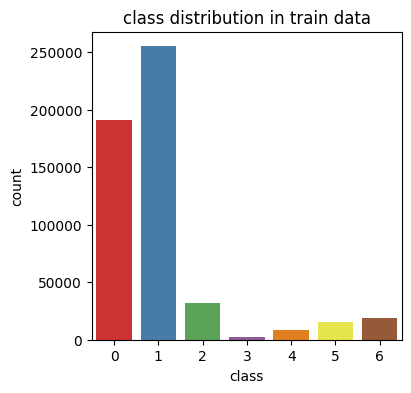

<ipython-input-9-8cc658d95234>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index,y=temp.values,palette='Set1')


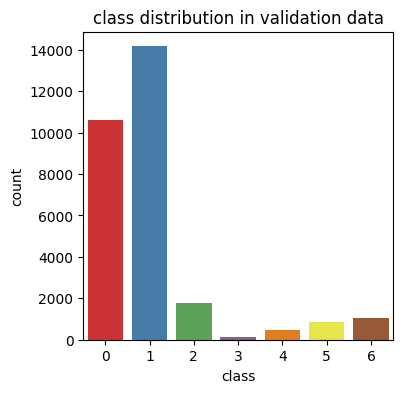

<ipython-input-9-8cc658d95234>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=temp.index,y=temp.values,palette='Set1')


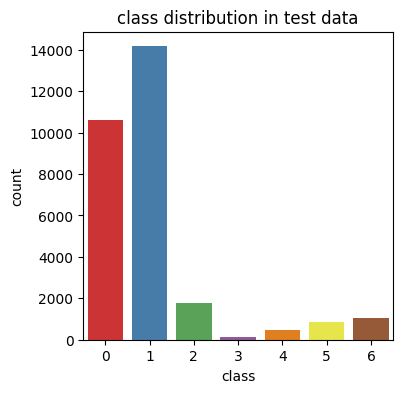

In [9]:
# train data
temp=y_train['Cover_Type'].value_counts().sort_index()

plt.figure(figsize=(4,4))
sns.barplot(x=temp.index,y=temp.values,palette='Set1')
plt.title('class distribution in train data')
plt.xlabel('class')
plt.ylabel('count')
plt.show()

# validation data
temp=y_val['Cover_Type'].value_counts().sort_index()

plt.figure(figsize=(4,4))
sns.barplot(x=temp.index,y=temp.values,palette='Set1')
plt.title('class distribution in validation data')
plt.xlabel('class')
plt.ylabel('count')
plt.show()

#test data
temp=y_test['Cover_Type'].value_counts().sort_index()

plt.figure(figsize=(4,4))
sns.barplot(x=temp.index,y=temp.values,palette='Set1')
plt.title('class distribution in test data')
plt.xlabel('class')
plt.ylabel('count')
plt.show()


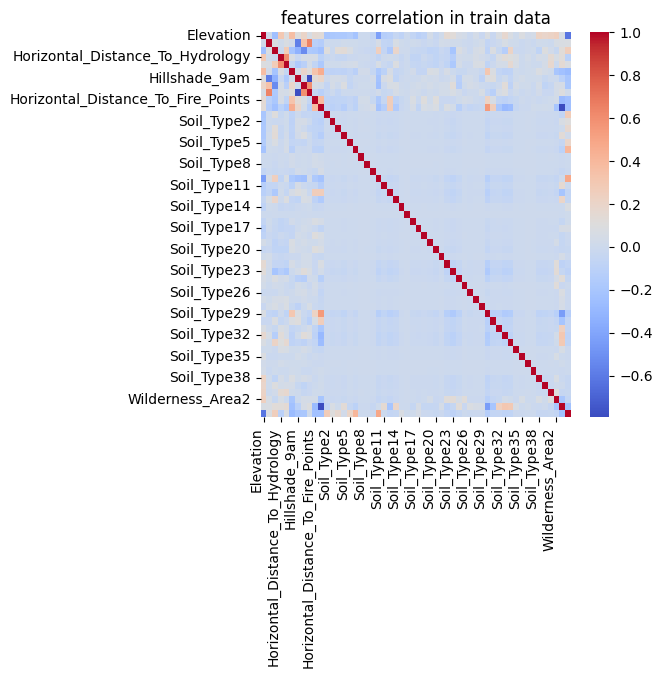

In [10]:
# heatmap
corr_matrix=X_train.corr()
plt.figure(figsize=(5,5))
sns.heatmap(corr_matrix,cmap='coolwarm')
plt.title('features correlation in train data')
plt.xticks(rotation=90,ha='right')
plt.show()


According to the diagram above, the features have little linear correlation with each other and it can be said that they are almost independent.

In [11]:
batch_size=256
epochs=150
lr=0.05

For this model, I initially set the learning rate to 0.15, but when I changed it to 0.05, the accuracy of the model improved. A high learning rate would cause the model to fluctuate around 75% accuracy and improve much later. Also, the batch size was initially larger. Although a larger batch size is better, a smaller batch size can help avoid local minima, so I reduced the batch size to 256.

### torch DataSet & DataLoader

In [12]:

train_data=TensorDataset(torch.tensor(X_train.values,dtype=torch.float32),torch.tensor(y_train.values.squeeze(),dtype=torch.int64))
train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)


validation_data=TensorDataset(torch.tensor(X_val.values,dtype=torch.float32),torch.tensor(y_val.values.squeeze(),dtype=torch.int64))
validation_loader=DataLoader(validation_data,batch_size=batch_size)

test_data=TensorDataset(torch.tensor(X_test.values,dtype=torch.float32),torch.tensor(y_test.values.squeeze(),dtype=torch.int64))
test_loader=DataLoader(test_data,batch_size=batch_size)


### Check for cuda

In [13]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### model

In [14]:
class NeuralNetwork(nn.Module):
  def __init__(self,hidden_size=256):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(54,hidden_size),
        nn.BatchNorm1d(hidden_size),
        nn.LeakyReLU(negative_slope=0.1),
        nn.Dropout(0.3),

        nn.Linear(hidden_size,hidden_size//2),
        nn.BatchNorm1d(hidden_size//2),
        nn.LeakyReLU(negative_slope=0.1),
        nn.Dropout(0.5),

        nn.Linear(hidden_size//2,hidden_size//4),
        nn.BatchNorm1d(hidden_size//4),
        nn.LeakyReLU(negative_slope=0.1),
        nn.Dropout(0.2),

        nn.Linear(hidden_size//4,hidden_size//8),
        #nn.BatchNorm1d(hidden_size//8),
        nn.LeakyReLU(negative_slope=0.1),
        nn.Dropout(0.1),

        nn.Linear(hidden_size//8,7),

        )
  def forward(self,x):
    return self.layers(x)



According to the research I did, it is better to use batch normalization in the initial and middle layers and preferably not to use it in the last layers. It should be used before the activation function so that in addition to preventing the inputs of the activation function from becoming too large or too small, and for some activation functions such as sigmoid, we do not fall into the saturation region and the gradient does not disappear, the distribution of the layer outputs does not change.

To prevent overfitting of the model, dropout layers are also used. The more parameters that layer has, the higher the probability we give to the dropout layer, so that the probability of overfitting the model is reduced.

Also, if we want to use batch normalization and random deletion together, we must be careful and use each in the right place, like in the code above.

It is better not to use batch normalization with a very small batch size because the mean and variance become noisy.

In [15]:
model=NeuralNetwork()

if device == 'cuda':
  model=model.to(device)

### loss function & optimizer

In [16]:
criterion=nn.CrossEntropyLoss()


# we use l2 regularization
optimizer=optim.Adam(model.parameters(),lr=lr,weight_decay=1e-6)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',patience=3)


### train & validate model

In [17]:
def train_and_validate(model,train_loader,validation_loader,epochs,batch_size):
  train_losses=[]
  val_losses=[]
  accuracies=[]

  #train
  for epoch in range(epochs):
    model.train()
    train_loss=0

    for inputs,labels in train_loader:
      if device == 'cuda':
        inputs=inputs.to(device)
        labels=labels.to(device)

      optimizer.zero_grad()

      predictions=model(inputs)
      loss=criterion(predictions,labels)

      loss.backward()

      optimizer.step()
      train_loss+=loss.item()


    # validate
    model.eval()
    val_loss=0
    corrects_num=0

    with torch.no_grad():
      for inputs , labels in validation_loader:
        if device == 'cuda':
          inputs=inputs.to(device)
          labels=labels.to(device)

        predictions=model(inputs)
        val_loss+=criterion(predictions,labels).item()
        a,predictions=torch.max(predictions,1)

        corrects_num+= (predictions == labels).sum().item()

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(validation_loader))
    accuracy=corrects_num/(len(validation_loader)*batch_size)
    accuracies.append(accuracy)

    scheduler.step(val_losses[-1])

    print(f'Epoch {epoch+1}/{epochs}:  Train loss:{train_losses[-1]:.4f},  Validation loss:{val_losses[-1]:.4f},  Accuracy:{accuracy:.4f}')

  return train_losses,val_losses,accuracies


In [18]:
train_losses,val_losses,accuracies = train_and_validate(model,train_loader,validation_loader,epochs,batch_size)

Epoch 1/150:  Train loss:0.6657,  Validation loss:0.5856,  Accuracy:0.7501
Epoch 2/150:  Train loss:0.6241,  Validation loss:0.5557,  Accuracy:0.7566
Epoch 3/150:  Train loss:0.6129,  Validation loss:0.5834,  Accuracy:0.7524
Epoch 4/150:  Train loss:0.6087,  Validation loss:0.5355,  Accuracy:0.7740
Epoch 5/150:  Train loss:0.6054,  Validation loss:0.5370,  Accuracy:0.7720
Epoch 6/150:  Train loss:0.6030,  Validation loss:0.5337,  Accuracy:0.7705
Epoch 7/150:  Train loss:0.6015,  Validation loss:0.5314,  Accuracy:0.7720
Epoch 8/150:  Train loss:0.6007,  Validation loss:0.5300,  Accuracy:0.7684
Epoch 9/150:  Train loss:0.5984,  Validation loss:0.5267,  Accuracy:0.7773
Epoch 10/150:  Train loss:0.5980,  Validation loss:0.5412,  Accuracy:0.7593
Epoch 11/150:  Train loss:0.5986,  Validation loss:0.5369,  Accuracy:0.7734
Epoch 12/150:  Train loss:0.5963,  Validation loss:0.5328,  Accuracy:0.7695
Epoch 13/150:  Train loss:0.5956,  Validation loss:0.5300,  Accuracy:0.7752
Epoch 14/150:  Train 

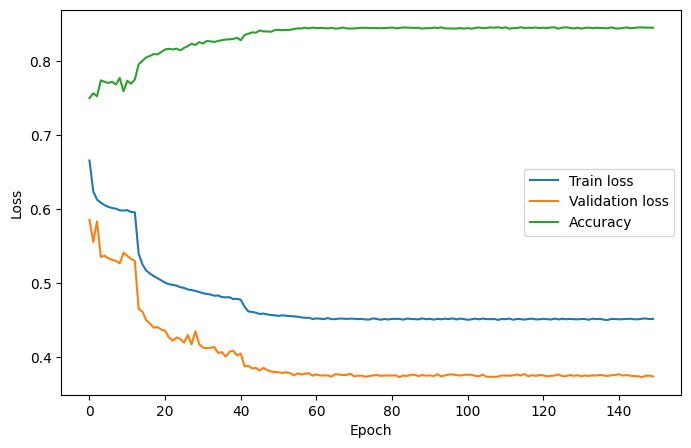

In [19]:
plt.figure(figsize=(8,5))
plt.plot(train_losses,label='Train loss')
plt.plot(val_losses,label='Validation loss')
plt.plot(accuracies,label='Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



### accuracy on test data

Accuracy on test data: 0.8435


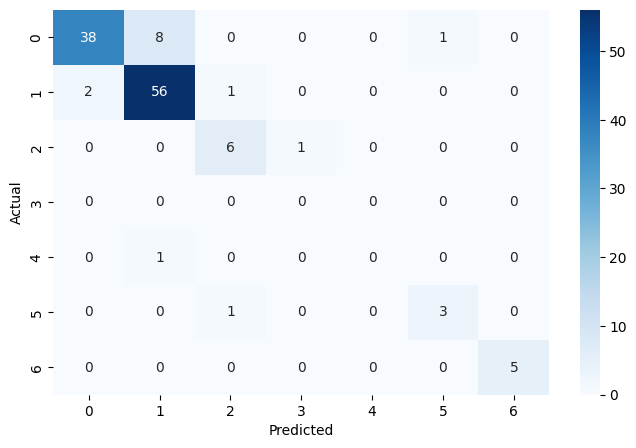

In [20]:
model.eval()
corrects_num=0
predictions2=np.array([])
labels2=np.array([])

with torch.no_grad():
  for inputs , labels in test_loader:
        if device == 'cuda':
          inputs=inputs.to(device)
          labels=labels.to(device)

        predictions=model(inputs)
        a,predictions=torch.max(predictions,1)
        predictions=predictions.cpu().numpy()
        labels=labels.cpu().numpy()
        corrects_num+= (predictions == labels).sum().item()

final_accuracy=corrects_num/(len(test_loader)*batch_size)
print(f'Accuracy on test data: {final_accuracy:.4f}')

confusion_matrix_=confusion_matrix(labels,predictions)
plt.figure(figsize=(8,5))
sns.heatmap(confusion_matrix_,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [21]:
from sklearn.metrics import classification_report
print(classification_report(labels,predictions))

              precision    recall  f1-score   support

           0       0.95      0.81      0.87        47
           1       0.86      0.95      0.90        59
           2       0.75      0.86      0.80         7
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         1
           5       0.75      0.75      0.75         4
           6       1.00      1.00      1.00         5

    accuracy                           0.88       123
   macro avg       0.62      0.62      0.62       123
weighted avg       0.88      0.88      0.88       123



According to the above information, the model does not perform well on classes 3 and 4, so we use the following method to generate synthetic data from these two classes for better model training

We can use smote to generate synthetic data.
The approach of this method is that, for example, 5 of the closest neighbors of the minority class data with the same class label are added to the data.

In [22]:

# from imblearn.over_sampling import SMOTE
# smote=SMOTE(sampling_strategy='auto',random_state=42)

# X_train_temp,y_train_temp=smote.fit_resample(X_train,y_train)
# X_train=np.vstack((X_train,X_train_temp))
# y_train=np.vstack((y_train,y_train_temp))

# train_data=TensorDataset(torch.tensor(X_train.values,dtype=torch.float32),torch.tensor(y_train.values.squeeze(),dtype=torch.int64))
# train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)


# validation_data=TensorDataset(torch.tensor(X_val.values,dtype=torch.float32),torch.tensor(y_val.values.squeeze(),dtype=torch.int64))
# validation_loader=DataLoader(validation_data,batch_size=batch_size)

# test_data=TensorDataset(torch.tensor(X_test.values,dtype=torch.float32),torch.tensor(y_test.values.squeeze(),dtype=torch.int64))
# test_loader=DataLoader(test_data,batch_size=batch_size)


In [23]:
# train_losses,val_losses,accuracies = train_and_validate(model,train_loader,validation_loader,epochs,batch_size)

In [24]:
# print(classification_report(labels,predictions))

Another solution that we can use to increase the accuracy of the model is Ensemble Learning. We can train several other models, such as neural networks with different architectures or even classical machine learning models such as logistic regression or decision trees or support vector machines for classification, and get a majority vote between these models and determine the final class. Usually, this method allows us to achieve higher accuracy, but the computational load during training and testing increases.